<a href="https://colab.research.google.com/github/flagg11/text_labaS/blob/laba2/Lab_2_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2

Цель работы: освоить основные подходы к решению задачи анализа тональности (sentiment analysis) для текстов на русском языке.

## Анализ тональности (Sentiment Analysis)

Анализ тональности - это задача определения эмоциональной окраски текста (например, положительная, отрицательная, нейтральная).

Модель должна понять, какое отношение выражает автор текста — например, в отзывах, комментариях, новостях или постах в соцсетях.
Примеры:

«Фильм просто великолепен!» - положительная тональность

«Обслуживание ужасное!» - отрицательная тональность

«Доставка заняла два дня.» - нейтральная тональность


In [30]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn pymorphy3 nltk

In [19]:
# Импорт необходимых библиотек
# Успешное выполнение этой ячейки кода подтверждает правильную настройку среды разработки

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import re
import nltk
from nltk.corpus import stopwords
import string
from tqdm.auto import tqdm
import os

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**Загрузка данных:**

Краткое описание датасета:

"**Обзор**:

Этот набор данных представляет собой обширную коллекцию русскоязычных обзоров и текстов, аннотированных для анализа тональности. Он предназначен для поддержки разработки и оценки моделей анализа настроений для русского языка. Набор данных сбалансирован по классам настроений (neutral, positive, negative), чтобы обеспечить справедливое обучение модели и ее оценку.

**Содержание**:

Набор данных составлен на основе нескольких общедоступных источников. Все исходные наборы данных были тщательно сбалансированы по классам тональности (нейтральная, положительная и отрицательная), чтобы обеспечить надёжность и непредвзятость набора данных.

**Структура набора данных**

Набор данных содержит следующие столбцы:

text: Текст рецензии или комментария.
label: Метка тональности, где:
0: нейтральная
1: положительная
2: отрицательная
src: Исходный набор данных."

Источник: https://www.kaggle.com/datasets/mar1mba/russian-sentiment-dataset

Загружаем данные из файла sentiment_dataset.csv в dataframe. Оставим только данные из набора с отзывами.

In [20]:
# Загрузка данных из sentiment_dataset.csv
print("Загрузка данных из файла 'sentiment_dataset.csv'...")

try:
    df = pd.read_csv('sentiment_dataset.csv')

    # Преобразование числовых меток в строковые для удобства
    sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}
    df['sentiment'] = df['label'].map(sentiment_map)

    # Оставим только отзывы из набора данных
    df = df[df['src'] == 'rureviews']

    print("Данные успешно загружены из 'sentiment_dataset.csv'. Первые 5 строк:")
    display(df.head())
    print("\nИнформация о данных:")
    df.info()
    print("\nРаспределение классов:")
    display(df['sentiment'].value_counts())

except FileNotFoundError:
    print("Файл данных 'sentiment_dataset.csv' не найден в текущей директории.")
except Exception as e:
    print(f"Произошла ошибка при загрузке или обработке данных: {e}")

Загрузка данных из файла 'sentiment_dataset.csv'...
Данные успешно загружены из 'sentiment_dataset.csv'. Первые 5 строк:


,text,label,src,sentiment
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews,neutral
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews,neutral
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews,neutral
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews,neutral
4,Мне не очень понравилось это платье. Размер ...,0,rureviews,neutral



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 86436 entries, 0 to 86435
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       86436 non-null  object
 1   label      86436 non-null  int64 
 2   src        86436 non-null  object
 3   sentiment  86436 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB

Распределение классов:


,count
sentiment,
neutral,28812
positive,28812
negative,28812


In [21]:
# Оставим только нужные нам значения
df = df[['text', 'sentiment', 'label']]

print(f'Таблца до проверки содержит {df.shape[0]} строк.\n')

# Удаляем строки с пропущенными значениями (если есть)
df = df.dropna()

print(f'Таблца без пропущенных значений содержит {df.shape[0]} строк.\n')

# Удаляем повторяющиеся отзывы (если есть)
duplicated_mask = df.duplicated(subset = 'text', keep = False)

print(f'Всего {np.sum(duplicated_mask)} повторяющихся отзывов в наборе данных.\n')

df = df.drop_duplicates(subset = 'text', keep = 'first')

print(f'Таблца без повторяющихся отзывов содержит {df.shape[0]} строк.\n')

Таблца до проверки содержит 86436 строк.

Таблца без пропущенных значений содержит 86436 строк.

Всего 0 повторяющихся отзывов в наборе данных.

Таблца без повторяющихся отзывов содержит 86436 строк.



Мы видим пример предварительно обработанного датасета: отсутствуют повторы и пропущенные значения в таблице. На практике всегда лучше проверить этот момент.

# Задание 1

Оставьте по 5000 строк для каждого класса в датасете (neutral, positive,negative). Всего должно получиться 15000 примеров. (Используйте sample())

Мы сильно сокращаем датасет для лабораторной работы, чтобы время обработки данных и обучения моделей было приемлемым. Однако на практике чем больше у нас разнообразных данных для обучения моделей, тем лучше результаты мы получм, если правильно подберём методы и настроим гиперпараметры.

In [22]:
# Сэмплирование данных: оставляем по 5000 строк для каждого уникального значения sentiment
print("Сэмплирование данных: оставляем по 5000 строк для каждого класса")

#### ВСТАВЬТЕ КОД СЮДА
df_neutral = df[df['sentiment'] == 'neutral'].sample(5000, random_state=42)
df_positive = df[df['sentiment'] == 'positive'].sample(5000, random_state=42)
df_negative = df[df['sentiment'] == 'negative'].sample(5000, random_state=42)

df = pd.concat([df_neutral, df_positive, df_negative], axis=0)
####

# Сбрасываем индекс
df.reset_index(drop=True, inplace=True)


print("\nИнформация о сэмплированных данных:\n")
df.info()
print("\nРаспределение классов после сэмплирования:\n")
display(df['sentiment'].value_counts())

Сэмплирование данных: оставляем по 5000 строк для каждого класса

Информация о сэмплированных данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       15000 non-null  object
 1   sentiment  15000 non-null  object
 2   label      15000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 351.7+ KB

Распределение классов после сэмплирования:



,count
sentiment,
neutral,5000
positive,5000
negative,5000


In [23]:
df

,text,sentiment,label
0,"Платье неплохое, но мне пришло с браком. По кр...",neutral,0
1,Невидимки в виде зигзага оказались очень мален...,neutral,0
2,"по качеству она более 1500 не стоит, размер за...",neutral,0
3,"Я заказывала женскую кофту（MRS） , а пришла муж...",neutral,0
4,"ставлю 3 звезды лишь за то, что продавец верну...",neutral,0
...,...,...,...
14995,В прошлом году у этого продавца покупала такие...,negative,2
14996,"Заказом не довольна.Качества на пол цены,отпра...",negative,2
14997,"Без маркировки , крой отличается от жилета мен...",negative,2
14998,"Мне не понравился цвет изделия, он не такой, к...",negative,2


Уже сейчас можно заметить, что для некоторых примеров однозначно определить настроение автора довольно сложно. Кроме того, для отзывов метка класса часто присваивается автоматически (датасет не размечается вручную), исходя из оценки, которую пользователь поставил товару или услуге. И эта оценка не всегда совпадает с содержанием отзыва (например, человек поставил 5 звёзд из 5 за товар, но в комментарии указал только то, что ему при этом не понравилось).

# Задание 2

**Предобработка текста:**

Проведите предварительную обработку текста в функции preprocess_text()

*   Приведение к нижнему регистру: Преобразуйте все слова в нижний регистр.
*   Удаление знаков пунктуации и специальных символов.
*   Удаление стоп-слов: Используйте список стоп-слов для русского языка для удаления часто встречающихся, но не несущих важную информацию для анализа слов.
*   Лемматизация: приведите слова к нормальной форме

In [24]:

#### ВСТАВЬТЕ КОД СЮДА

from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()
russian_stopwords = stopwords.words('russian')

def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление пунктуации и спецсимволов
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)

    # Токенизация
    words = text.split()

    # Удаление стоп-слов и лемматизация
    lemmas = [morph.parse(word)[0].normal_form for word in words if word not in russian_stopwords]

    return " ".join(lemmas)

####

print("\nНачало предобработки текста...")
# Применение предобработки к столбцу с текстом. Используем tqdm для отслеживания прогресса.
if 'text' in df.columns:
    tqdm.pandas()
    df['processed_text'] = df['text'].progress_apply(preprocess_text)
    print("Предобработка текста завершена.")
    display(df.head())


Начало предобработки текста...


  0%|          | 0/15000 [00:00<?, ?it/s]

Предобработка текста завершена.


,text,sentiment,label,processed_text
0,"Платье неплохое, но мне пришло с браком. По кр...",neutral,0,платье неплохой прийти брак крайний мера замет...
1,Невидимки в виде зигзага оказались очень мален...,neutral,0,невидимка вид зигзаг оказаться очень маленький...
2,"по качеству она более 1500 не стоит, размер за...",neutral,0,качество 1500 стоить размер заказать м реальны...
3,"Я заказывала женскую кофту（MRS） , а пришла муж...",neutral,0,заказывать женский кофту（mrs） прийти мужской （ms）
4,"ставлю 3 звезды лишь за то, что продавец верну...",neutral,0,ставить 3 звезда лишь продавец вернуть деньга ...


# Задание 3

**Извлечение признаков:**
(Токенизация и векторизация текстов)

Преобразуйте предобработанный текст в числовое представление, пригодное для обучения модели. Используйте метод TF-IDF (Term Frequency-Inverse Document Frequency), реализованнный в классе TfidfVectorizer. В соответствии с вашим вариантом установите количество самых часто встречающихся слов из формируемого словаря VOCABULARY_SIZE, которые будут использоваться при векторизации ("количество слов в словаре").


**Разделение данных:**

Разделите данные на тренировочную и тестовую выборки в соответствии с вашим вариантом ("процент тестовой выборки от объёма всего датасета").

In [25]:
#### ВСТАВЬТЕ КОД СЮДА

VOCABULARY_SIZE = 30000
# Подготовка данных для модели


X = df['processed_text']
y = df['sentiment']


# Разделение данных на обучающую и тестовую выборки
# Используйте stratify=y для сохранения распределения классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nДанные разделены на обучающую ({len(X_train)} примеров) и тестовую ({len(X_test)} примеров) выборки.")
print("Распределение классов в обучающей выборке:")
display(y_train.value_counts())
print("Распределение классов в тестовой выборке:")
display(y_test.value_counts())


# Извлечение признаков с помощью TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=VOCABULARY_SIZE)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

####
print(f"TF-IDF признаки извлечены. Размерность обучающей выборки: {X_train_tfidf.shape}")


Данные разделены на обучающую (11250 примеров) и тестовую (3750 примеров) выборки.
Распределение классов в обучающей выборке:


,count
sentiment,
neutral,3750
positive,3750
negative,3750


Распределение классов в тестовой выборке:


,count
sentiment,
negative,1250
neutral,1250
positive,1250


TF-IDF признаки извлечены. Размерность обучающей выборки: (11250, 9954)


# Задание 4

**Обучение модели:**

Обучите модель классификации на тренировочной выборке.

В зависимости от вашего варианта используйте наивный байесовский классификатор (`sklearn.naive_bayes.MultinomialNB`), логистическую регрессию (`sklearn.linear_model.LogisticRegression`), или метод опорных векторов с линейным ядром (`sklearn.svm.LinearSVC`).


In [26]:

#### ВСТАВЬТЕ КОД СЮДА

model = LinearSVC()
model.fit(X_train_tfidf, y_train)

# Оценка модели (предсказание)
y_pred = model.predict(X_test_tfidf)

####

**Оценка модели:**
Оцените производительность обученной модели на тестовой выборке. Рассчитайте метрики: точность (accuracy), полнота (recall) и F1-мера для каждого класса (положительный, отрицательный, нейтральный), а также общую точность.

**Интерпретация результатов:** Проанализируйте полученные метрики. Попробуйте найти примеры отзывов, которые были классифицированы правильно и неправильно. Объясните, почему модель могла ошибиться в конкретных случаях.

In [27]:
# Используем zero_division=0 для корректного расчета метрик при отсутствии предсказаний для класса
# Получаем все уникальные метки из набора данных для корректного расчета метрик
all_labels = ['neutral', 'positive', 'negative']
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=all_labels, zero_division=0) # Расчет по классам
accuracy = accuracy_score(y_test, y_pred)

print("\nРезультаты оценки модели:")
print(f"Общая точность (Accuracy): {accuracy:.4f}")

# Вывод метрик по классам
metrics_df = pd.DataFrame({
    'Sentiment': all_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})
print("\nМетрики по классам:")
display(metrics_df)

# Примеры предсказаний
print("\nПримеры предсказаний:")
# Выбираем примеры случайным образом из тестовой выборки для демонстрации
example_indices = X_test.sample(5).index
examples = df.loc[example_indices]
examples['predicted_sentiment'] = model.predict(tfidf_vectorizer.transform(examples['processed_text']))

for index, row in examples.iterrows():
    print(f"\nОригинальный отзыв: {row['text']}")
    print(f"Предобработанный отзыв: {row['processed_text']}")
    print(f"Истинная тональность: {row['sentiment']}")
    print(f"Предсказанная тональность: {row['predicted_sentiment']}")


Результаты оценки модели:
Общая точность (Accuracy): 0.6827

Метрики по классам:


,Sentiment,Precision,Recall,F1-score
0,neutral,0.573025,0.5744,0.573712
1,positive,0.787030,0.7864,0.786715
2,negative,0.688301,0.6872,0.687750



Примеры предсказаний:

Оригинальный отзыв: платье пришло быстро. это единственный плюс. нитки торчат везде, зацепаются за ногти, получаются затяжки. нижнее платье пришло с дыркой. открыла спор...   началось. продавец предложил вернуть копейки. я не успела ответить, т.к. не было интернета, в итоге али по спору решили, что я должна вернуть товар. естественно, это бред полный, т.к. посылка туда обошлась бы в 2р дороже самого платья. тех.поддержка писала мне каждый раз что они решают мой вопрос и все будет ок после закрытия спора продавец мне вернет хотя бы эти копейки. продавец долго мазался типа дада верну, но типа не знаю как. Как вернуть ему объяснили раз 5... но увы...спор закрылся, продавец загасился.
Предобработанный отзыв: платье прийти быстро это единственный плюс нитка торчать везде зацепаться ноготь получаться затяжка нижний платье прийти дырка открыть спор начаться продавец предложить вернуть копейка успеть ответить так интернет итог али спор решить должный вернуть товар естес

# LSTM модель в анализе тональности

LSTM (Long Short-Term Memory) используют в анализе тональности, потому что она умеет:
- понимать контекст и порядок слов,
- запоминать важные слова в длинных предложениях,
- игнорировать несущественные,
- учитывать зависимость между словами, находящимися далеко друг от друга.

**Тональность — это контекстная задача**

Чтобы определить эмоциональную окраску текста, модель должна понимать смысл фразы целиком, а не просто набор слов.

Например:

«Фильм не плохой» - положительная тональность

«Фильм не только скучный, но и затянутый» - отрицательная

Здесь ключевую роль играет слово “не” и его положение относительно прилагательного.

Обычные модели вроде TF-IDF не понимают контекст, в отличие от LSTM.

**LSTM обрабатывает текст как последовательность**

LSTM — это тип рекуррентной нейросети (RNN), которая читает текст по одному слову за раз и запоминает, что было раньше.

Пример:

«Фильм был скучным, но актёры великолепны.»

Чтобы правильно определить тональность, модель должна помнить, что вторая часть фразы меняет общий смысл.

LSTM хранит эту информацию во внутренней памяти — state.

**Проблема «долгой памяти» и её решение**

Обычные RNN не умеют сохранять контекст на длинных промежутках —
градиенты затухают (vanishing gradient).

LSTM решает это с помощью механизма ячеек памяти и трёх "вентилей":

Вентиль	 -  Что делает

* Forget gate	 -  решает, какую старую информацию забыть
* Input gate	 -  решает, что добавить в память
* Output gate	 -  решает, какую часть памяти передать дальше

Благодаря этому LSTM может запомнить даже дальние зависимости:
в предложении «Хотя фильм местами скучный, в целом он отличный» модель понимает, что тональность положительная, несмотря на слово «скучный».

**Работа с последовательностями переменной длины**

В текстах отзывы бывают короткими и длинными.
LSTM умеет работать с последовательностями разной длины (через pad_sequences),
что делает её гибкой для реальных данных.

## Векторизация: подход для сохранения порядка слов
Ранее мы пользовались методом `texts_to_matrix()` класса `Tokenizer()` и его аналогом у `TfidfVectorizer` `transform()`. С помощью этого метода мы получаем матрицу признаков размера [num_texts, num_words] - document-term matrix. То есть каждый документ кодируется вектором фиксированной длины, равной длине используемого для кодирования словаря.

Теперь нас будет интересовать метод `texts_to_sequences()`, который преобразует каждый текст в последовательность индексов слов (список номеров последовательных токенов). То есть длина векторов будет напрямую зависеть от длины документов (отзывов). Этот метод сохраняет **порядок слов**.
Каждому слову присваивается индекс из словаря Tokenizer.word_index.

`texts_to_sequences()` используется для:

*   LSTM / GRU
*   Embedding слоя
*   Моделей, где важен порядок слов

И не подходит для полносвязных сетей без Embedding, так как размерность последовательностей может отличаться (нужно дополнительно применять pad_sequences).


In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Сделаем задачу бинарной классификации для упрощения, уберём нейтральные отзывы
texts = df[df['sentiment'] != 'neutral'].processed_text

tokenizer = Tokenizer(num_words=VOCABULARY_SIZE, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)


In [36]:
texts.iloc[0] #

'соответствовать описание доставка 20 день свердловский область'

In [37]:
sequences[0]

[24, 61, 12, 263, 30, 2426, 284]

In [38]:
# Находим максимальную длину последовательности
max_len = max(len(seq) for seq in sequences)
print(f"Максимальная длина последовательности: {max_len}")

Максимальная длина последовательности: 153


In [39]:
# Заполняем нулями вектор в конце отзыва, чтобы сделать входные векторы одинаковой длины
X = pad_sequences(sequences, maxlen=max_len, padding='post')

print("Пример последовательности:", X[0])
print("Размер X:", X.shape)

Пример последовательности: [  24   61   12  263   30 2426  284    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]
Размер X: (10000, 153)


In [40]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import utils

y_df = df[df['sentiment'] != 'neutral'].sentiment
y = list(y_df.values)

y = y_df.factorize()[0]

In [41]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [42]:
# Делим на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Архитектура глубокой сети в TensorFlow Keras (продолжение)

### Embedding слой в LSTM

**Что такое Embedding слой?**

Embedding слой в моделях для обработки естественного языка используется для преобразования дискретных входных данных (слов) в плотные векторы фиксированного размера. Вместо того чтобы представлять каждое слово как отдельный уникальный элемент (например, в one-hot кодировании), Embedding слой отображает слова в многомерное векторное пространство, где слова с похожим значением или контекстом находятся ближе друг к другу.

**Зачем он нужен в LSTM?**

В контексте LSTM (и других рекуррентных нейронных сетей) Embedding слой выполняет несколько важных функций:

1.  **Снижение размерности:** One-hot кодирование для большого словаря приводит к очень разреженным и высокоразмерным векторам. Embedding слой позволяет представить слова в гораздо более низкоразмерном пространстве, что делает обучение более эффективным и снижает вычислительные затраты.
2.  **Захват семантических связей:** В процессе обучения Embedding слой изучает векторные представления слов, которые отражают их семантические и синтаксические отношения.
3.  **Улучшение производительности:** Плотные векторные представления, генерируемые Embedding слоем, лучше подходят для входных данных LSTM, поскольку они предоставляют более богатую и информативную репрезентацию слов по сравнению с разреженными представлениями.

**Как задается в TensorFlow (Keras)?**

Embedding слой в TensorFlow Keras задается с помощью класса `tf.keras.layers.Embedding`. Основные параметры:

*   `input_dim`: Размер словаря (общее количество уникальных слов + 1 для зарезервированных индексов, например, для паддинга или неизвестных слов). Уже учитываем это при векторизации.
*   `output_dim`: Размерность выходного вектора (размерность эмбеддинга). Это гиперпараметр, который нужно настраивать.
*   `input_length`: Максимальная длина входных последовательностей (текстов).

### LSTM слой

**Что такое LSTM?**

LSTM (Long Short-Term Memory) - это особый тип рекуррентной нейронной сети (RNN), предназначенный для обработки последовательных данных, таких как текст, речь или временные ряды. Ключевое отличие LSTM от простых RNN заключается в наличии специальной структуры - **ячейки памяти (cell state)** и **вентилей (gates)**, которые позволяют LSTM эффективно учиться и запоминать зависимости на длинных последовательностях, преодолевая проблему "исчезающего градиента" (vanishing gradient problem), характерную для простых RNN.

**Зачем нужен LSTM?**

В задачах обработки текста, таких как анализ тональности, машинный перевод или генерация текста, важен контекст и порядок слов. LSTM способен улавливать эти зависимости, даже если слова, влияющие на смысл, находятся далеко друг от друга в предложении. Это делает LSTM мощным инструментом для понимания и обработки естественного языка.

**Как задается в TensorFlow (Keras)?**

LSTM слой в TensorFlow Keras задается с помощью класса `tf.keras.layers.LSTM`. Основные параметры:

*   `units`: Количество ячеек (нейронов) в слое LSTM. Это определяет размерность выходного вектора слоя.
*   `activation`: Функция активации для выходных данных (по умолчанию 'tanh').
*   `recurrent_activation`: Функция активации для рекуррентных шагов (по умолчанию 'sigmoid').
*   `use_bias`: Использовать ли смещение (bias).
*   `kernel_initializer`, `recurrent_initializer`, `bias_initializer`: Методы инициализации весов.
*   `dropout`: Вероятность отбрасывания нейронов на входе слоя (для регуляризации).
*   `recurrent_dropout`: Вероятность отбрасывания рекуррентных соединений (для регуляризации).



### SpatialDropout1D vs Dropout

Оба `Dropout` и `SpatialDropout1D` являются техниками регуляризации, используемыми для предотвращения переобучения нейронных сетей. Они делают это путем случайного "выключения" (обнуления) некоторых нейронов или элементов входных данных во время обучения. Однако, они применяют эту операцию по-разному, что делает `SpatialDropout1D` особенно полезным для последовательных данных, таких как текст.

**Dropout:**

*   **Как работает:** Случайным образом устанавливает в ноль отдельные элементы входного тензора с заданной вероятностью `rate`.
*   **Применение:** Обычно используется в полносвязных слоях (`Dense`).
*   **Проблема с последовательными данными:** При применении `Dropout` напрямую к выходу слоя Embedding или другим слоям, работающим с последовательностями (например, LSTM), он может случайно отбрасывать отдельные слова или их представления. Это может нарушить пространственные (временные) зависимости между соседними словами, которые важны для понимания контекста в тексте.

**SpatialDropout1D:**

*   **Как работает:** Случайным образом устанавливает в ноль целые каналы (например, целые признаки для всех слов в последовательности) входного тензора с заданной вероятностью `rate`. Для 1D данных (как в нашем случае с текстом), это означает, что если один признак (например, определенная размерность вектора эмбеддинга) отбрасывается для одного слова в последовательности, то он отбрасывается для *всех* слов в этой последовательности.
*   **Применение:** Особенно полезен после слоев Embedding или других слоев, работающих с последовательностями.
*   **Преимущество для последовательных данных:** `SpatialDropout1D` сохраняет пространственные (временные) корреляции между признаками. Вместо того чтобы отбрасывать отдельные слова, он отбрасывает целые признаки для всех слов. Это помогает предотвратить переобучение, сохраняя при этом целостность последовательных данных и их контекстуальные зависимости.

**В чем разница?**

Основное отличие заключается в том, что `Dropout` отбрасывает отдельные элементы, тогда как `SpatialDropout1D` отбрасывает целые *каналы* признаков по всем временным шагам (для 1D данных). Для текстов, где порядок и взаимосвязь слов важны, `SpatialDropout1D` часто дает лучшие результаты, поскольку он не разрушает локальные структуры в данных так сильно, как обычный `Dropout`.

# Задание 5

Задайте архитектуру LSTM модели в Tensorflow Keras, состяющую из следующих псоледовательно расположенных слоёв:


*   Embedding - output_dim = 16
*   Bidirectional LSTM - 32 нейрона
*   Полносвязный Dense - 10 нейронов и функция активации ReLU
*   Полносвязный Dense - 1 нейрон и функция активации sigmoid

У нас задача бинарной классификации, оптимизатор Adam, метрика - точность.

Обучите полученную модель.

Дополнительно:* При желании попробуйте поэкспериментировать с архитектурой и гиперпараметрами.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SpatialDropout1D, Embedding, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam


#### ВСТАВЬТЕ КОД СЮДА

embedding_vector_length = 16

model_tf = Sequential()
model_tf.add(Embedding(input_dim=VOCABULARY_SIZE+1, output_dim=embedding_vector_length, input_length=X_train.shape[1]))
model_tf.add(SpatialDropout1D(0.2))
model_tf.add(Bidirectional(LSTM(32)))
model_tf.add(Dense(10, activation='relu'))
model_tf.add(Dense(1, activation='sigmoid'))

model_tf.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

history = model_tf.fit(X_train, y_train, validation_split=0.2, epochs=7, batch_size=64)
####

Epoch 1/7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6063 - loss: 0.6555 - val_accuracy: 0.8550 - val_loss: 0.3549
Epoch 2/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8901 - loss: 0.2918 - val_accuracy: 0.9006 - val_loss: 0.2455
Epoch 3/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9262 - loss: 0.1958 - val_accuracy: 0.9137 - val_loss: 0.2169
Epoch 4/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9458 - loss: 0.1468 - val_accuracy: 0.9100 - val_loss: 0.2107
Epoch 5/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9591 - loss: 0.1212 - val_accuracy: 0.9044 - val_loss: 0.2350
Epoch 6/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9615 - loss: 0.1019 - val_accuracy: 0.9081 - val_loss: 0.2573
Epoch 7/7
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9679 - loss: 0.0888 - val_accuracy: 0.9100 - val_loss: 0.2543


In [44]:
# Обучение модели
history = model_tf.fit(X_train, y_train, validation_split=0.2, epochs=7)

Epoch 1/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9747 - loss: 0.0769 - val_accuracy: 0.8969 - val_loss: 0.2974
Epoch 2/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9726 - loss: 0.0807 - val_accuracy: 0.9050 - val_loss: 0.3028
Epoch 3/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9799 - loss: 0.0627 - val_accuracy: 0.9013 - val_loss: 0.3246
Epoch 4/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9840 - loss: 0.0412 - val_accuracy: 0.8944 - val_loss: 0.3311
Epoch 5/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9853 - loss: 0.0524 - val_accuracy: 0.8950 - val_loss: 0.3458
Epoch 6/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9865 - loss: 0.0437 - val_accuracy: 0.9000 - val_loss: 0.3620
Epoch 7/7
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9888 - loss: 0.0420 - val_accuracy: 0.8913 - val_loss: 0.3876


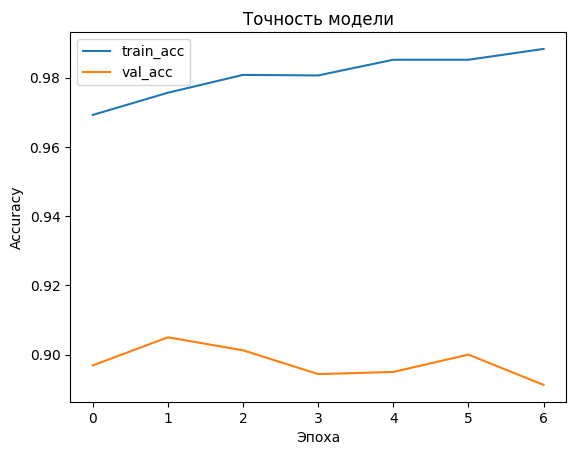

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Анализ тональности с моделью BERT

Использование трансформеров в задаче анализа тональности считается лучшим подходом к решению на данный момент.

Вы можете попробовать использовать одну из предобученных BERT моделей для разметки своего датасета для курсовой в задаче анализа тональности.

In [46]:
from transformers import pipeline
# Более лёгкая модель
model = pipeline(model="seara/rubert-tiny2-russian-sentiment")
# seara/rubert-base-cased-russian-sentiment - тяжёлая модель с большим количеством параетров и ожидаемыми хорошими результатами
model("Привет, ты мне нравишься!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


[{'label': 'positive', 'score': 0.939876914024353}]

In [47]:
# Применение модели тональности к 5 примерам из столбца 'text'
# import pandas as pd

if 'df' in locals() and 'text' in df.columns and not df.empty:
      # Примеры предсказаний
    print("\nПримеры предсказаний:")
    # Выбираем примеры случайным образом из тестовой выборки для демонстрации
    example_indices = df['processed_text'].sample(5, random_state=42).index
    examples = df.loc[example_indices]
    examples['predicted_sentiment'] = model(examples['text'].tolist())
    examples['predicted_sentiment'] = examples['predicted_sentiment'].apply(lambda x: x['label'])

    for index, row in examples.iterrows():
        print(f"\nОригинальный отзыв: {row['text']}")
        # print(f"Предобработанный отзыв: {row['processed_text']}")
        print(f"Истинная тональность: {row['sentiment']}")
        print(f"Предсказанная тональность (BERT): {row['predicted_sentiment']}")



Примеры предсказаний:

Оригинальный отзыв: Кофта очень короткая, не соответсвует описанию. Открыла спор, продавец деньги не вернул сказал что это дизайнерская задумка, но в описании и на картинке совершенно выглядит по другому! В общем ни продавца ни товар не рекомендую. 
Истинная тональность: negative
Предсказанная тональность (BERT): negative

Оригинальный отзыв: кофта очень мягкая! Рукова немного узковаты, на рост 170 короткие, пару раз поносила, и рукова расстянулись в ширь. быстро закатывается, синтетика. кофта а один сезон
Истинная тональность: positive
Предсказанная тональность (BERT): neutral

Оригинальный отзыв: Футболка очень короткая.Продавец отказывается вернуть деньги,а в последнее время и вовсе игнорирует мои сообщения.
Истинная тональность: negative
Предсказанная тональность (BERT): negative

Оригинальный отзыв: Нормально,у кого грудь большая самый большой размер не пойдет;(;(так что смотрите сами)
Истинная тональность: neutral
Предсказанная тональность (BERT): neutral


In [48]:
examples

,text,sentiment,label,processed_text,predicted_sentiment
11499,"Кофта очень короткая, не соответсвует описанию...",negative,2,кофта очень короткий соответсвовать описание о...,negative
6475,"кофта очень мягкая! Рукова немного узковаты, н...",positive,1,кофта очень мягкий рукова немного узковатый ро...,neutral
13167,Футболка очень короткая.Продавец отказывается ...,negative,2,футболка очень короткий продавец отказываться ...,negative
862,"Нормально,у кого грудь большая самый большой р...",neutral,0,нормально кто грудь больший самый большой разм...,neutral
5970,"Куртка супер, тонкая как раз на теплую осень, ...",positive,1,куртка супер тонкий тёплый осень заказывать до...,positive


In [49]:
def bert_model(text):
    if isinstance(text, str):
        return model(text)[0]['label']
    return "" # Возвращаем пустую строку для нестроковых значений

print("Начинаем предсказывать")
tqdm.pandas()
df['predicted_sentiment'] = df['processed_text'].progress_apply(bert_model)
print("Закончили предсказывать.")
display(df.head())

Начинаем предсказывать


  0%|          | 0/15000 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Закончили предсказывать.


,text,sentiment,label,processed_text,predicted_sentiment
0,"Платье неплохое, но мне пришло с браком. По кр...",neutral,0,платье неплохой прийти брак крайний мера замет...,neutral
1,Невидимки в виде зигзага оказались очень мален...,neutral,0,невидимка вид зигзаг оказаться очень маленький...,neutral
2,"по качеству она более 1500 не стоит, размер за...",neutral,0,качество 1500 стоить размер заказать м реальны...,neutral
3,"Я заказывала женскую кофту（MRS） , а пришла муж...",neutral,0,заказывать женский кофту（mrs） прийти мужской （ms）,neutral
4,"ставлю 3 звезды лишь за то, что продавец верну...",neutral,0,ставить 3 звезда лишь продавец вернуть деньга ...,neutral


In [50]:
df

,text,sentiment,label,processed_text,predicted_sentiment
0,"Платье неплохое, но мне пришло с браком. По кр...",neutral,0,платье неплохой прийти брак крайний мера замет...,neutral
1,Невидимки в виде зигзага оказались очень мален...,neutral,0,невидимка вид зигзаг оказаться очень маленький...,neutral
2,"по качеству она более 1500 не стоит, размер за...",neutral,0,качество 1500 стоить размер заказать м реальны...,neutral
3,"Я заказывала женскую кофту（MRS） , а пришла муж...",neutral,0,заказывать женский кофту（mrs） прийти мужской （ms）,neutral
4,"ставлю 3 звезды лишь за то, что продавец верну...",neutral,0,ставить 3 звезда лишь продавец вернуть деньга ...,neutral
...,...,...,...,...,...
14995,В прошлом году у этого продавца покупала такие...,negative,2,прошлый год продавец покупать такой брюки отли...,neutral
14996,"Заказом не довольна.Качества на пол цены,отпра...",negative,2,заказ довольный качество пол цена отправка оче...,neutral
14997,"Без маркировки , крой отличается от жилета мен...",negative,2,маркировка крой отличаться жилет малый размер ...,neutral
14998,"Мне не понравился цвет изделия, он не такой, к...",negative,2,понравиться цвет изделие картинка вырез очень ...,neutral


In [51]:
precision, recall, f1, _ = precision_recall_fscore_support(df['sentiment'], df['predicted_sentiment'], average=None, labels=all_labels, zero_division=0) # Расчет по классам
accuracy = accuracy_score(df['sentiment'], df['predicted_sentiment'])

In [52]:
print("\nРезультаты оценки модели:")
print(f"Общая точность (Accuracy): {accuracy:.4f}")

# Вывод метрик по классам
metrics_df = pd.DataFrame({
    'Sentiment': all_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})
print("\nМетрики по классам:")
display(metrics_df)


Результаты оценки модели:
Общая точность (Accuracy): 0.6685

Метрики по классам:


,Sentiment,Precision,Recall,F1-score
0,neutral,0.512270,0.8308,0.633763
1,positive,0.867412,0.7602,0.810275
2,negative,0.826226,0.4146,0.552137


In [53]:
df.iloc[2]['text']

'по качеству она более 1500 не стоит, размер заказала М - реальный наш 42. отправка с 11.11 до 27.11'

In [54]:
df.iloc[2]

,2
text,"по качеству она более 1500 не стоит, размер за..."
sentiment,neutral
label,0
processed_text,качество 1500 стоить размер заказать м реальны...
predicted_sentiment,neutral


Какие выводы можно сделать на основании полученных метрик?

Подумайте о возможных подходах к улучшению точности на этапе предварительной обработки, токенизации и векторизации текста (использование биграмм, корректирование списка стоп-слов, ...).